In [ ]:
# !pip install pandas numpy matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


# PHẦN 1: KHỞI TẠO MÔI TRƯỜNG
Trước khi bắt đầu, chúng ta cần nhập các thư viện cần thiết:
* **Pandas & Numpy:** Để thao tác và xử lý dữ liệu dạng bảng và số học.
* **Matplotlib & Seaborn:** Để vẽ biểu đồ trực quan hóa dữ liệu (EDA).
* **Re (Regex):** Để xử lý chuỗi ký tự và trích xuất thông tin từ địa chỉ.

Cấu hình `warnings.filterwarnings('ignore')` giúp notebook gọn gàng hơn bằng cách ẩn các cảnh báo không quan trọng.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

# Cấu hình hiển thị
pd.set_option('display.max_columns', None) # Hiển thị tất cả cột
pd.set_option('display.max_colwidth', 100) # Hiển thị nội dung dài
sns.set_style("whitegrid") # Giao diện biểu đồ sáng sủa
warnings.filterwarnings('ignore') # Tắt cảnh báo

# PHẦN 2: ĐỌC DỮ LIỆU (DATA LOADING)
Chúng ta sẽ đọc file `data_homedy_full.csv` vào DataFrame của Pandas.
Bước này cũng kiểm tra xem file có tồn tại hay không để tránh lỗi chương trình bị dừng đột ngột.

In [ ]:
try:
    df = pd.read_csv('data_homedy_full.csv')
    pd.read_csv()
    print(f"Đọc file thành công! Kích thước dữ liệu: {df.shape}")
    print("-" * 30)
    print("3 dòng đầu tiên của dữ liệu:")
    display(df.head(3))
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'data_homedy_full.csv'. Kiểm tra đường dẫn.")

Đọc file thành công! Kích thước dữ liệu: (180, 7)
------------------------------
3 dòng đầu tiên của dữ liệu:


,url,title,price,area,address,description,source
0,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/chdv-30m2-gac-cao-cua...,"CHDV 30m2 gác cao cửa sổ lớn đường Giải Phóng Tân Bình chỉ 5,5 triệu",5500000,30.0,"Cho thuê Nhà trọ, phòng trọ Đường Giải Phóng - Phường 4, Quận Tân Bình, TP Hồ Chí Minh",CHÍNH CHỦ CHO THUÊ CHDV ĐƯỜNG GIẢI PHÓNG TÂN BÌNH CÓ GÁC CHỈ 5 TRIỆU 500k - Địa chỉ: Đường Giải...,homedy.com
1,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-tan-binh-tp-ho-chi-minh/con-duy-nhat-1-duong-...,"Còn duy nhất 1 phòng cho thuê_ Đường Hoàng Văn Thụ, P.2, Q. Tân Bình, Hồ Chí Minh",3500000,26.0,"Cho thuê Nhà trọ, phòng trọ Đường Hoàng Văn Thụ - Phường 2, Quận Tân Bình, TP Hồ Chí Minh","Khu dân cư yên tĩnh, an ninh, ngay vòng xoay Lăng Cha Cả. Thuận tiện di chuyển muôn nơi (3-5 phú...",homedy.com
2,https://homedy.com/cho-thue-nha-tro-phong-tro-quan-7-tp-ho-chi-minh/tang-1-152-duong-so-39-phuon...,"Cho thuê phòng tầng 1, 152 đường số 39, phường Tân Hưng, Tp.HCM",4500000,15.0,"Cho thuê Nhà trọ, phòng trọ Đường Số 39 - Phường Tân Hưng, Quận 7, TP Hồ Chí Minh","Cho thuê phòng tầng 1, 152 đường số 39, phường Tân Hưng, Tp.HCM Phòng đã lắp sẵn máy lạnh, sạch ...",homedy.com


# PHẦN 3: TIỀN XỬ LÝ & LÀM SẠCH (DATA CLEANING)
Theo nguyên tắc **"Garbage In, Garbage Out"** (Rác vào thì Rác ra), đây là bước quan trọng nhất.

Chúng ta sẽ thực hiện 4 tác vụ:
1.  **Xóa cột rác (Garbage Collection):** Loại bỏ `url`, `source`, `Unnamed: 0` vì chúng không giúp mô hình dự đoán giá nhà.
2.  **Xử lý trùng lặp (De-duplication):** Dữ liệu cào web thường bị lặp lại do một tin được đăng nhiều lần. Ta sẽ xóa các dòng trùng nhau hoàn toàn.
3.  **Ép kiểu (Type Casting):** Chuyển đổi `price` và `area` từ dạng chuỗi sang dạng số. Các giá trị lỗi (vd: "Thỏa thuận") sẽ bị chuyển thành `NaN`.
4.  **Lọc nhiễu (Filtering):** Áp dụng kiến thức thực tế (Domain Knowledge):
    * Xóa các dòng bị `NaN`.
    * Loại bỏ tin có Giá < 500k hoặc Diện tích < 5m2 (thường là dữ liệu rác hoặc lỗi nhập liệu).

In [5]:
# 1. Xóa cột rác
cols_to_drop = ['source', 'url']
if 'Unnamed: 0' in df.columns:
    cols_to_drop.append('Unnamed: 0')

df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"-> Đã xóa các cột: {cols_to_drop}")

# 2. Xử lý trùng lặp
before = len(df)
df = df.drop_duplicates(subset=['title', 'price', 'area', 'address'])
print(f"-> Đã xóa {before - len(df)} dòng trùng lặp.")

# 3. Ép kiểu dữ liệu (errors='coerce' sẽ biến lỗi thành NaN)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['area'] = pd.to_numeric(df['area'], errors='coerce')

# 4. Lọc nhiễu và xử lý NaN
df = df.dropna(subset=['price', 'area']) # Xóa dòng NaN
df = df[(df['price'] > 500000) & (df['area'] > 5)] # Lọc theo logic thực tế

print(f"Dữ liệu sạch còn lại: {len(df)} dòng.")

-> Đã xóa các cột: ['source', 'url']
-> Đã xóa 1 dòng trùng lặp.
Dữ liệu sạch còn lại: 171 dòng.


In [12]:
# Lưu DataFrame hiện tại ra file CSV mới
# index=False: Để không lưu cột số thứ tự (0,1,2...) vào file, tránh tạo thêm cột rác
# encoding='utf-8-sig': Để mở bằng Excel không bị lỗi font tiếng Việt
df.to_csv('data_homedy_step3.csv', index=False, encoding='utf-8-sig')

print("✅ Đã lưu file thành công: data_homedy_step3.csv")

✅ Đã lưu file thành công: data_homedy_step3.csv


# PHẦN 4: KỸ THUẬT VỚI BIẾN SỐ (NUMERICAL FEATURE ENGINEERING)
**Lý thuyết:** Dữ liệu tài chính (như Giá nhà) thường tuân theo **Phân phối đuôi dài (Power Law)** thay vì Phân phối chuẩn (Normal Distribution). Điều này làm cho các mô hình học máy hoạt động kém hiệu quả.

**Giải pháp:** Sử dụng kỹ thuật **Log Transformation**.
Hàm `np.log1p(x) = log(x + 1)` giúp "co" dải giá trị lớn lại, biến phân phối trở nên giống hình chuông (Bell curve) hơn, giúp mô hình học tốt hơn.

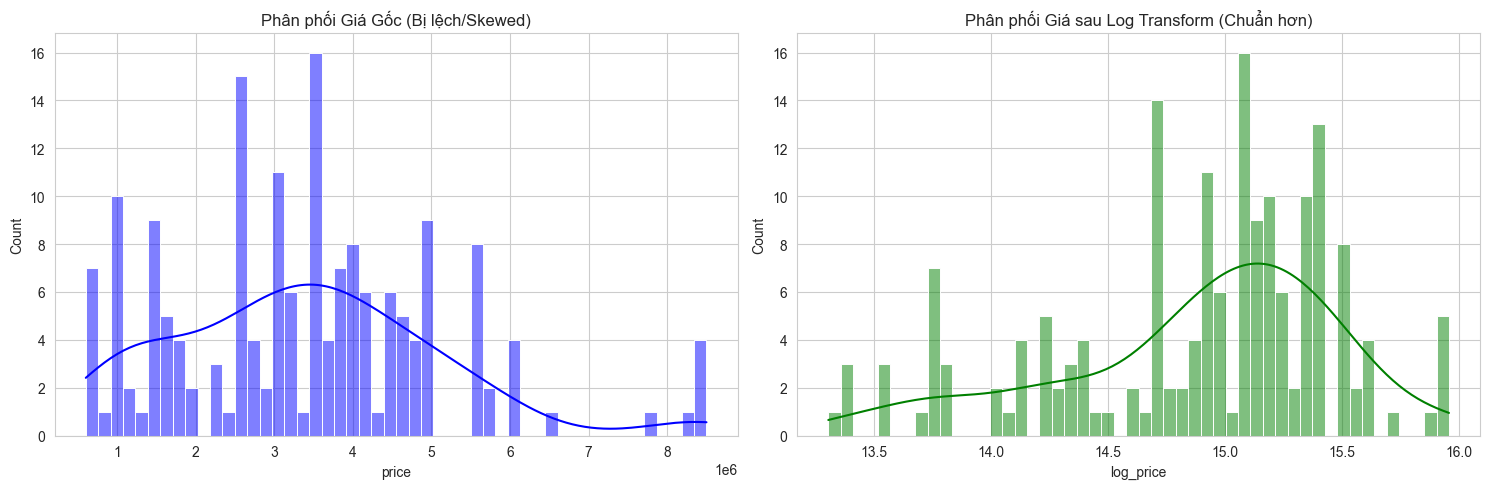

In [ ]:
# Tạo đặc trưng mới: Log của Giá
df['log_price'] = np.log1p(df['price'])

# Vẽ biểu đồ so sánh
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ gốc (Thường bị lệch trái)
sns.histplot(df['price'], bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Phân phối Giá Gốc (Bị lệch/Skewed)')
ax[0].ticklabel_format(style='plain', axis='x') # Tắt format khoa học 1e6

# Biểu đồ sau log (Dạng chuẩn)
sns.histplot(df['log_price'], bins=50, kde=True, ax=ax[1], color='green')
ax[1].set_title('Phân phối Giá sau Log Transform (Chuẩn hơn)')

plt.tight_layout()
plt.show()

# PHẦN 5: XỬ LÝ BIẾN ĐỊA CHỈ (CATEGORICAL VARIABLES)
**Vấn đề:** Cột `address` chứa quá nhiều giá trị duy nhất (High Cardinality) do bao gồm cả tên đường, số nhà... Nếu đưa thẳng vào mô hình sẽ gây nhiễu (Overfitting).

**Giải pháp (Binning):** Chúng ta sẽ trích xuất thông tin cấp cao hơn là **Quận/Huyện**.
Chúng ta dùng **Regular Expression (Regex)** để bắt các cụm từ như "Quận 1", "Huyện Nhà Bè", "TP Thủ Đức".

In [ ]:
def extract_district(addr):
    """Hàm dùng Regex để bắt tên Quận/Huyện từ địa chỉ"""
    if not isinstance(addr, str):
        return "Khác"
    # Regex bắt: Quận X, Huyện Y, TP Thủ Đức (kể cả viết tắt TP.)
    match = re.search(r'(Quận\s[\w\d]+|Huyện\s[\w\d]+|Thành phố\sThủ Đức|TP\sThủ Đức|TP\.\sThủ Đức)', addr, re.IGNORECASE)
    if match:
        return match.group(0).title() # Viết hoa chữ cái đầu
    return "Khác"

# Áp dụng hàm
df['district'] = df['address'].apply(extract_district)

# Trực quan hóa Top 15 khu vực
plt.figure(figsize=(12, 6))
top_districts = df['district'].value_counts().head(15)
sns.barplot(x=top_districts.values, y=top_districts.index, palette='viridis')
plt.title('Top 15 Khu vực có lượng tin đăng nhiều nhất')
plt.xlabel('Số lượng tin')
plt.show()

# PHẦN 6: KHAI THÁC DỮ LIỆU VĂN BẢN (TEXT MINING)
Thay vì xử lý NLP phức tạp, ta dùng phương pháp **"Dictionary-based filtering"** để tạo các biến nhị phân (0/1).

Chúng ta trả lời câu hỏi: *Tin đăng này có chứa từ khóa X không?*
* `has_furniture`: Có từ khóa "nội thất", "full option"... hay không?
* `has_aircon`: Có "máy lạnh", "điều hòa" hay không?
* `has_balcony`: Có "ban công", "cửa sổ" hay không?

Đây là các yếu tố tác động mạnh đến giá thuê.

In [ ]:
# Tạo các biến chỉ báo (Indicator Variables)
# 1. Nội thất
df['has_furniture'] = df['description'].str.contains('nội thất|full option|tiện nghi', case=False, na=False).astype(int)
# 2. Máy lạnh
df['has_aircon'] = df['description'].str.contains('máy lạnh|điều hòa', case=False, na=False).astype(int)
# 3. Ban công
df['has_balcony'] = df['description'].str.contains('ban công|cửa sổ|thoáng', case=False, na=False).astype(int)

# Vẽ biểu đồ Boxplot để xem tác động của nội thất đến giá
plt.figure(figsize=(8, 5))
sns.boxplot(x='has_furniture', y='log_price', data=df, palette="Set2")
plt.title('Tác động của Nội thất đến Giá thuê (Thang đo Log)')
plt.xticks([0, 1], ['Không có/Ko ghi', 'Có nội thất'])
plt.ylabel('Log Price')
plt.show()

# Kiểm tra con số thực tế
mean_yes = df[df['has_furniture']==1]['price'].mean()
mean_no = df[df['has_furniture']==0]['price'].mean()
print(f"💰 Giá trung bình CÓ nội thất: {mean_yes:,.0f} VND")
print(f"💰 Giá trung bình KHÔNG nội thất: {mean_no:,.0f} VND")